# Rolling PCA — Residuals and Signal Construction

This notebook runs the full pre-trading pipeline:

1. **Rolling PCA** — extract $k$ common factors from a $L$-day window of standardised returns  
2. **Method B regression residuals** — per-stock OLS of raw returns on PCA factor scores; residual $\varepsilon_{i,t}$ is the idiosyncratic component  
3. **Rolling z-score** — standardise residuals over an $M$-day window so signals are comparable across stocks  
4. **Signal construction** — threshold and quantile versions of the mean-reversion signal

**Main spec:** $L = 60$, $k = 5$, $M = 60$, threshold $c = 1.0$, quantile $q = 0.10$  
**Timing rule:** at date $t$, all estimates use only data through $t-1$. Positions open at $t$, returns earned $t \to t+1$.

In [ ]:
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tqdm import tqdm

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

PROCESSED = "../data/processed"
INTERIM   = "../data/interim"

# Main spec
L_MAIN         = 60    # PCA estimation window (trading days)
K_MAIN         = 5     # number of PCA factors retained
M_MAIN         = 60    # rolling window for z-score standardisation
THRESHOLD_MAIN = 1.0   # |z| threshold for entering a position
Q_MAIN         = 0.10  # quantile signal: long bottom Q, short top Q

In [2]:
log_returns = pd.read_parquet(f"{PROCESSED}/log_returns.parquet")

print(f"Shape : {log_returns.shape[0]} days × {log_returns.shape[1]} stocks")
print(f"Dates : {log_returns.index.min().date()}  →  {log_returns.index.max().date()}")
log_returns.iloc[:3, :5]

Shape : 3730 days × 200 stocks
Dates : 2011-06-27  →  2026-04-27


Ticker,TSLA,NVDA,AAPL,MSFT,AMZN
Date,,,,,
2011-06-27,-0.003998,-0.021189,0.017285,0.036368,0.044192
2011-06-28,0.023395,0.005823,0.009651,0.023530,0.005451
2011-06-29,0.006383,0.015365,-0.003646,-0.007001,0.009003


### Rolling PCA + Regression Residuals

The model for each stock $i$ on day $\tau$ within the rolling window is:

$$r_{i,\tau} = \alpha_i + \beta_i^\top F_\tau + \varepsilon_{i,\tau}$$

where $F_\tau \in \mathbb{R}^k$ are PCA factor scores extracted from **standardised** returns (so they capture co-movement, not volatility magnitude), and the regression is on **raw** returns. This gives residuals $\varepsilon_{i,\tau}$ in raw return units, interpretable directly as unexplained daily P&L.

The regression is vectorised across all $N$ stocks in one `lstsq` call per window.

In [7]:
def rolling_pca_residuals(returns: pd.DataFrame, L: int, k: int):
    """
    Returns
    -------
    residuals      : DataFrame (T-L, N)  raw-return residuals from OLS
    evr            : DataFrame (T-L, k)  explained variance ratio per PC
    factor_returns : DataFrame (T-L, k)  PCA factor scores for the last day of each window
    loadings_last  : ndarray  (k, N)     PC directions from the final window (for inspection)
    """
    T, N    = returns.shape
    dates   = returns.index[L:]
    tickers = returns.columns

    resid_rows  = np.full((T - L, N), np.nan)
    evr_rows    = np.full((T - L, k), np.nan)
    factor_rows = np.full((T - L, k), np.nan)
    loadings_last = None

    R_vals = returns.values

    for i, t in enumerate(tqdm(range(L, T), desc=f"L={L}, k={k}")):
        window = R_vals[t - L : t].copy()       # (L, N) raw returns

        # Fill NaN with each stock's within-window mean (keeps the stock in the model
        # rather than dropping it; imputing the mean is neutral for PCA and OLS)
        nan_mask = np.isnan(window)
        if nan_mask.any():
            col_means = np.nanmean(window, axis=0)
            col_means = np.where(np.isnan(col_means), 0.0, col_means)
            rows, cols = np.where(nan_mask)
            window[rows, cols] = col_means[cols]

        # Standardise within window for PCA
        mu  = window.mean(axis=0)
        sig = window.std(axis=0, ddof=1)
        sig = np.where(sig == 0, 1.0, sig)
        R_std = (window - mu) / sig             # (L, N)

        # PCA on standardised returns → factor scores
        pca = PCA(n_components=k)
        F   = pca.fit_transform(R_std)          # (L, k)

        # Method B: OLS of raw returns on factor scores, vectorised over stocks
        F_aug = np.column_stack([np.ones(L), F])            # (L, k+1) with intercept
        coef, _, _, _ = np.linalg.lstsq(F_aug, window, rcond=None)  # (k+1, N)
        resid = window - F_aug @ coef           # (L, N)

        resid_rows[i]  = resid[-1]              # residual for day t-1
        evr_rows[i]    = pca.explained_variance_ratio_
        factor_rows[i] = F[-1]                  # factor score for day t-1

        if i == T - L - 1:
            loadings_last = pca.components_     # (k, N)

    residuals      = pd.DataFrame(resid_rows,  index=dates, columns=tickers)
    evr            = pd.DataFrame(evr_rows,    index=dates, columns=[f"PC{j+1}" for j in range(k)])
    factor_returns = pd.DataFrame(factor_rows, index=dates, columns=[f"PC{j+1}" for j in range(k)])

    return residuals, evr, factor_returns, loadings_last

In [8]:
residuals, evr, factor_returns, loadings_last = rolling_pca_residuals(
    log_returns, L=L_MAIN, k=K_MAIN
)

print(f"Residuals      : {residuals.shape}")
print(f"EVR            : {evr.shape}")
print(f"Factor returns : {factor_returns.shape}")
print(f"Date range     : {residuals.index.min().date()}  →  {residuals.index.max().date()}")

L=60, k=5:   0%|          | 0/3670 [00:00<?, ?it/s]/var/folders/w5/w5gx4xh14rn74jbyx12z69gh0000gn/T/ipykernel_23493/725315743.py:46: RuntimeWarning: divide by zero encountered in matmul
  resid = window - F_aug @ coef           # (L, N)
/var/folders/w5/w5gx4xh14rn74jbyx12z69gh0000gn/T/ipykernel_23493/725315743.py:46: RuntimeWarning: overflow encountered in matmul
  resid = window - F_aug @ coef           # (L, N)
/var/folders/w5/w5gx4xh14rn74jbyx12z69gh0000gn/T/ipykernel_23493/725315743.py:46: RuntimeWarning: invalid value encountered in matmul
  resid = window - F_aug @ coef           # (L, N)
/var/folders/w5/w5gx4xh14rn74jbyx12z69gh0000gn/T/ipykernel_23493/725315743.py:46: RuntimeWarning: divide by zero encountered in matmul
  resid = window - F_aug @ coef           # (L, N)
/var/folders/w5/w5gx4xh14rn74jbyx12z69gh0000gn/T/ipykernel_23493/725315743.py:46: RuntimeWarning: overflow encountered in matmul
  resid = window - F_aug @ coef           # (L, N)
/var/folders/w5/w5gx4xh14rn74jby

Residuals      : (3670, 200)
EVR            : (3670, 5)
Factor returns : (3670, 5)
Date range     : 2011-09-21  →  2026-04-27


The share of total return variation captured by the top $k$ components tells us how much of the cross-section is driven by common factors vs. idiosyncratic moves. Crisis periods typically show a spike — stocks become more correlated and PC1 dominates.

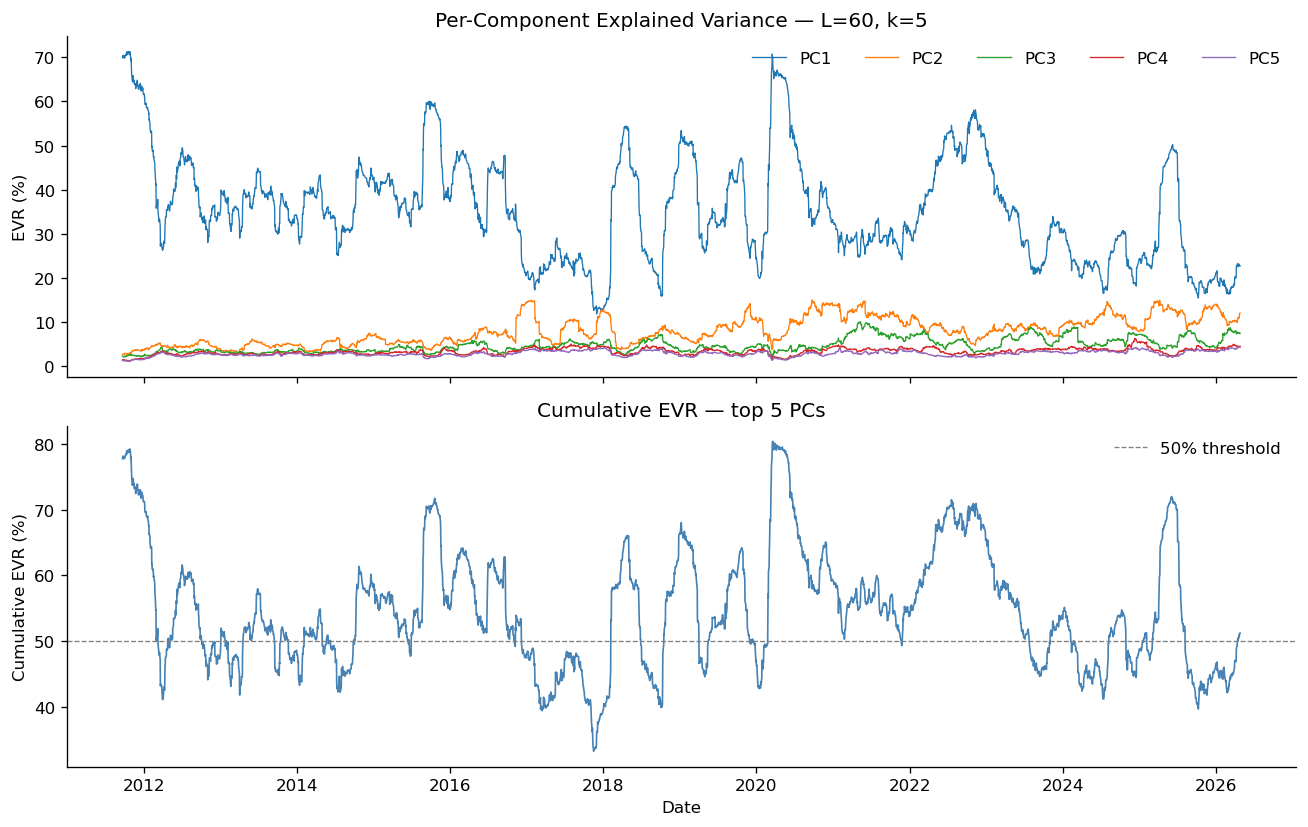

Mean cumulative EVR (k=5): 54.6%
Min : 33.3%
Max : 80.4%


In [9]:
cumulative_evr = evr.cumsum(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax = axes[0]
colors = plt.cm.tab10.colors
for j, col in enumerate(evr.columns):
    ax.plot(evr.index, evr[col] * 100, label=col, linewidth=0.8, color=colors[j])
ax.set_ylabel("EVR (%)")
ax.set_title(f"Per-Component Explained Variance — L={L_MAIN}, k={K_MAIN}")
ax.legend(frameon=False, ncol=5)

ax = axes[1]
ax.plot(cumulative_evr.index, cumulative_evr[f"PC{K_MAIN}"] * 100, color="steelblue", linewidth=1)
ax.axhline(50, color="grey", linewidth=0.8, linestyle="--", label="50% threshold")
ax.set_ylabel("Cumulative EVR (%)")
ax.set_xlabel("Date")
ax.set_title(f"Cumulative EVR — top {K_MAIN} PCs")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

print(f"Mean cumulative EVR (k={K_MAIN}): {cumulative_evr[f'PC{K_MAIN}'].mean():.1%}")
print(f"Min : {cumulative_evr[f'PC{K_MAIN}'].min():.1%}")
print(f"Max : {cumulative_evr[f'PC{K_MAIN}'].max():.1%}")

PC1 should show most stocks loading with the same sign — a broad market factor. Later PCs have mixed signs, reflecting sector or style tilts. These are statistical factors, not named economic factors.

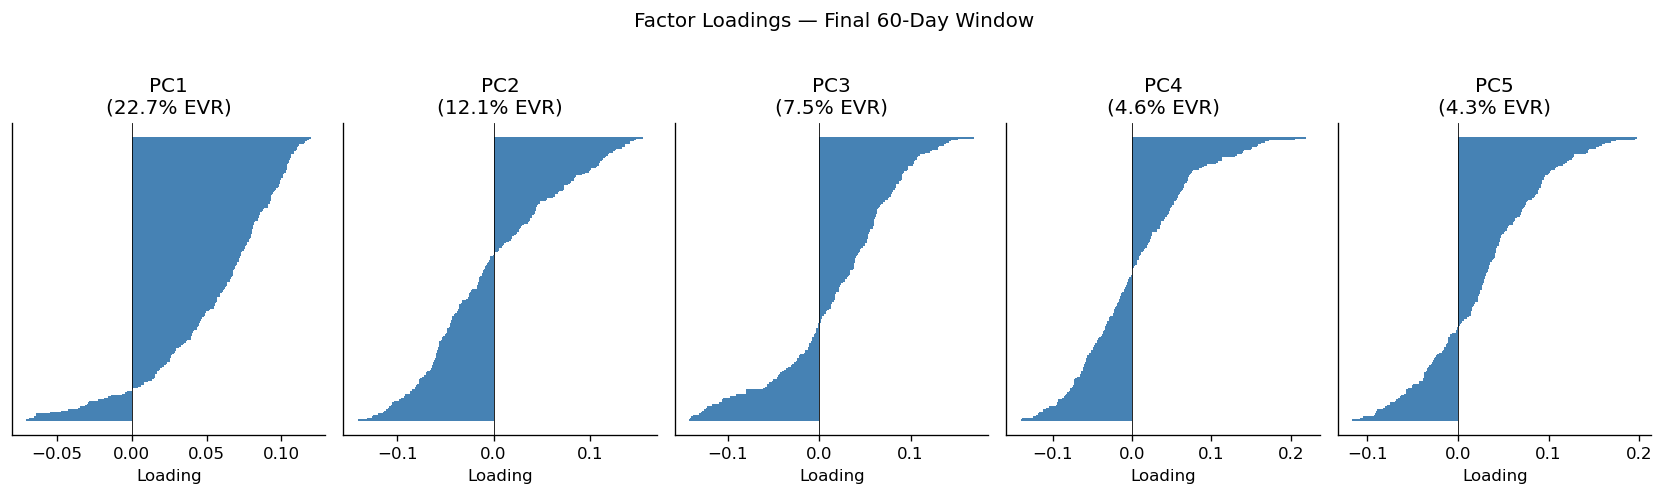

In [10]:
loadings_df = pd.DataFrame(
    loadings_last.T,
    index=log_returns.columns,
    columns=[f"PC{j+1}" for j in range(K_MAIN)],
)

fig, axes = plt.subplots(1, K_MAIN, figsize=(14, 4), sharey=False)
for j, ax in enumerate(axes):
    col = f"PC{j+1}"
    sorted_loads = loadings_df[col].sort_values()
    ax.barh(range(len(sorted_loads)), sorted_loads.values, color="steelblue", edgecolor="none", height=1.0)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_yticks([])
    ax.set_xlabel("Loading")
    ax.set_title(f"{col}\n({evr[col].iloc[-1]:.1%} EVR)")

fig.suptitle(f"Factor Loadings — Final {L_MAIN}-Day Window", y=1.02)
plt.tight_layout()
plt.show()

Cumulative residuals for a few stocks should oscillate around zero — a visual check that the residual series has no persistent trend (which would indicate a missing factor or a broken implementation).

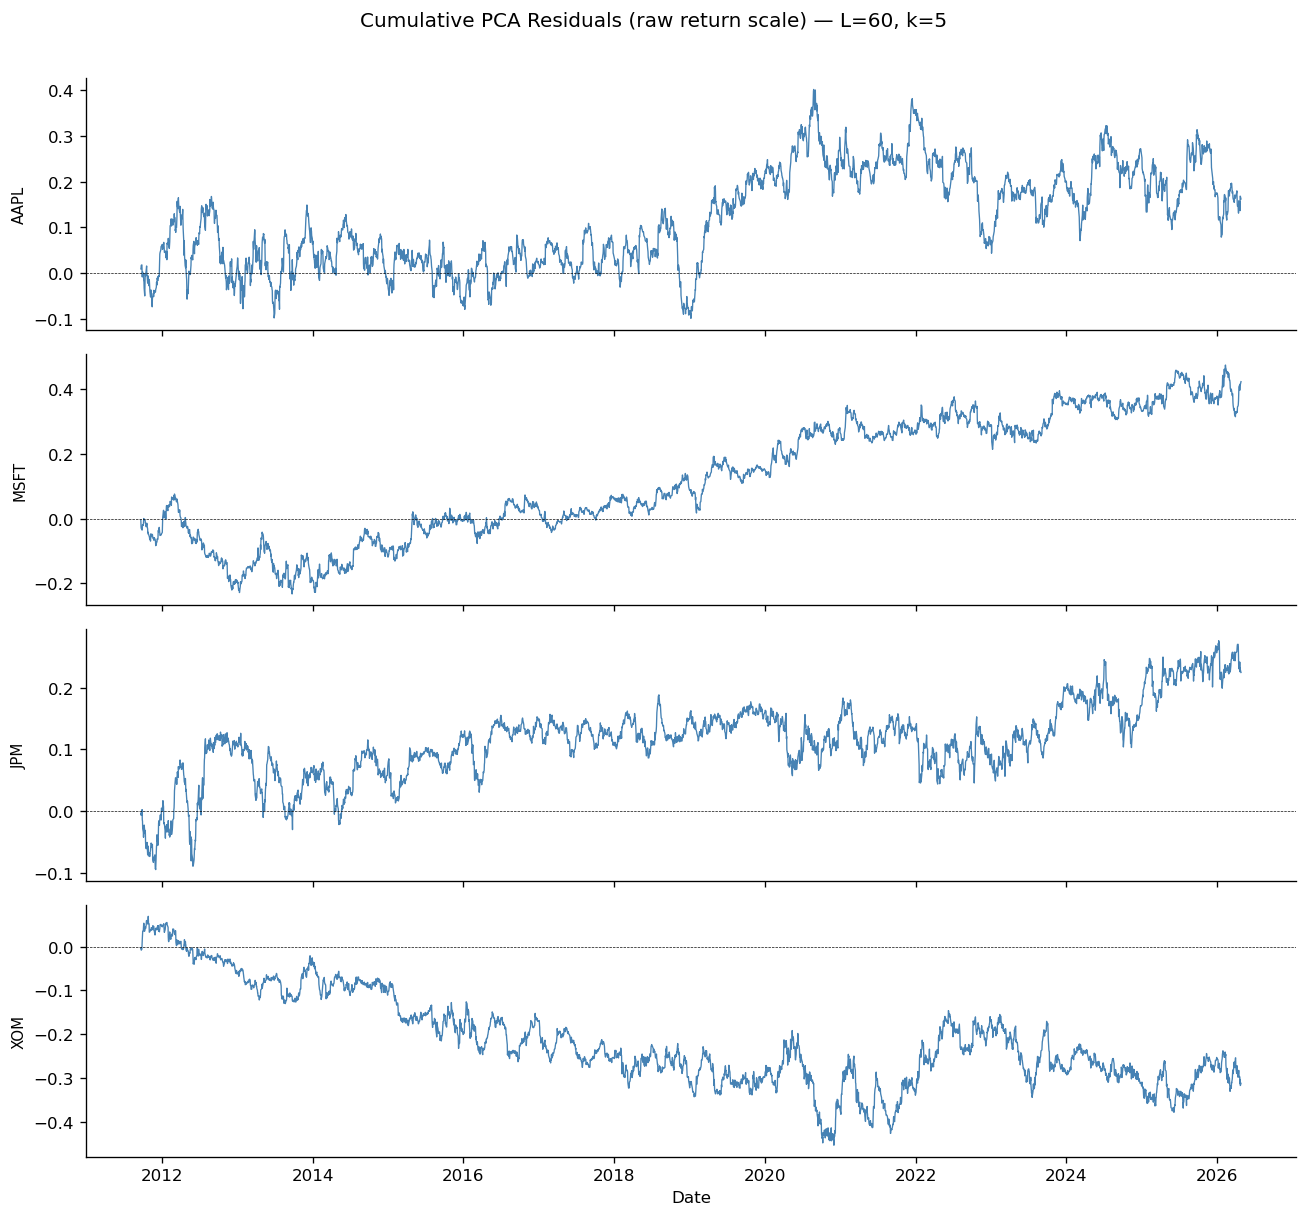

In [11]:
example_tickers = [t for t in ["AAPL", "MSFT", "JPM", "XOM"] if t in residuals.columns]

fig, axes = plt.subplots(len(example_tickers), 1, figsize=(11, 2.5 * len(example_tickers)), sharex=True)
if len(example_tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, example_tickers):
    cumr = residuals[ticker].cumsum()
    ax.plot(cumr.index, cumr.values, linewidth=0.8, color="steelblue")
    ax.axhline(0, color="black", linewidth=0.4, linestyle="--")
    ax.set_ylabel(ticker, fontsize=9)

axes[-1].set_xlabel("Date")
fig.suptitle(f"Cumulative PCA Residuals (raw return scale) — L={L_MAIN}, k={K_MAIN}", y=1.01)
plt.tight_layout()
plt.show()

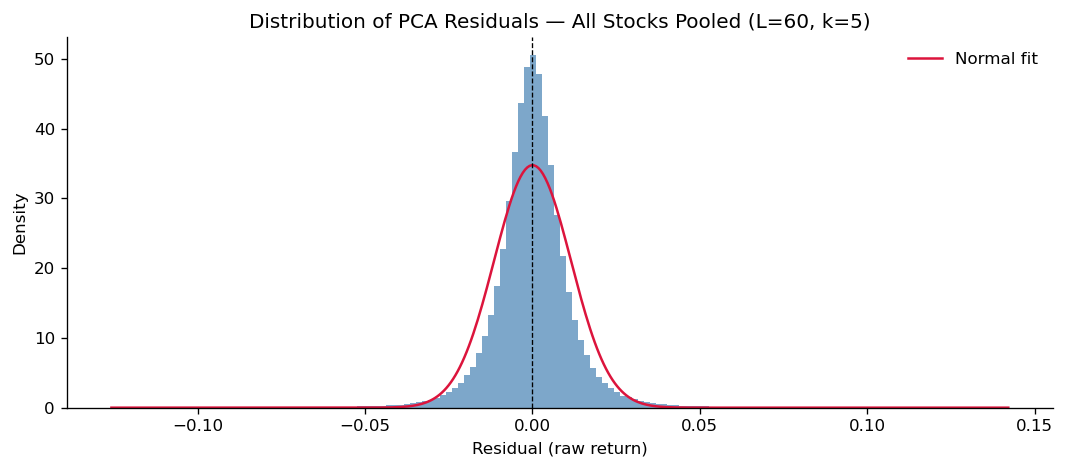

Mean : 0.000017  (should be ~0)
Std  : 0.011480


In [12]:
pooled_resid = residuals.values.flatten()
pooled_resid = pooled_resid[~np.isnan(pooled_resid)]

mu_r, sig_r = pooled_resid.mean(), pooled_resid.std()
x = np.linspace(pooled_resid.min(), pooled_resid.max(), 400)
normal_pdf = np.exp(-0.5 * ((x - mu_r) / sig_r) ** 2) / (sig_r * np.sqrt(2 * np.pi))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(pooled_resid, bins=150, density=True, color="steelblue", alpha=0.7, edgecolor="none")
ax.plot(x, normal_pdf, color="crimson", linewidth=1.5, label="Normal fit")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Residual (raw return)")
ax.set_ylabel("Density")
ax.set_title(f"Distribution of PCA Residuals — All Stocks Pooled (L={L_MAIN}, k={K_MAIN})")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Mean : {mu_r:.6f}  (should be ~0)")
print(f"Std  : {sig_r:.6f}")

### Rolling Z-Score Construction

Raw residuals are not comparable across stocks — AAPL's idiosyncratic volatility differs from XOM's. We standardise each stock's residual series using its own rolling history:

$$z_{i,t} = \frac{\varepsilon_{i,t} - \mu_{i,t}^{(\varepsilon)}}{\sigma_{i,t}^{(\varepsilon)}}$$

where $\mu$ and $\sigma$ are computed over the prior $M = 60$ residuals for stock $i$.

The first valid z-score date is $L + M = 120$ trading days into the sample.

In [13]:
mu_e  = residuals.rolling(M_MAIN).mean()
sig_e = residuals.rolling(M_MAIN).std(ddof=1)

zscores = (residuals - mu_e) / sig_e
zscores = zscores.dropna(how="all")

print(f"Z-scores : {zscores.shape[0]} days × {zscores.shape[1]} stocks")
print(f"Dates    : {zscores.index.min().date()}  →  {zscores.index.max().date()}")
print(f"\nFirst L+M={L_MAIN+M_MAIN} days consumed by estimation windows")

Z-scores : 3611 days × 200 stocks
Dates    : 2011-12-14  →  2026-04-27

First L+M=120 days consumed by estimation windows


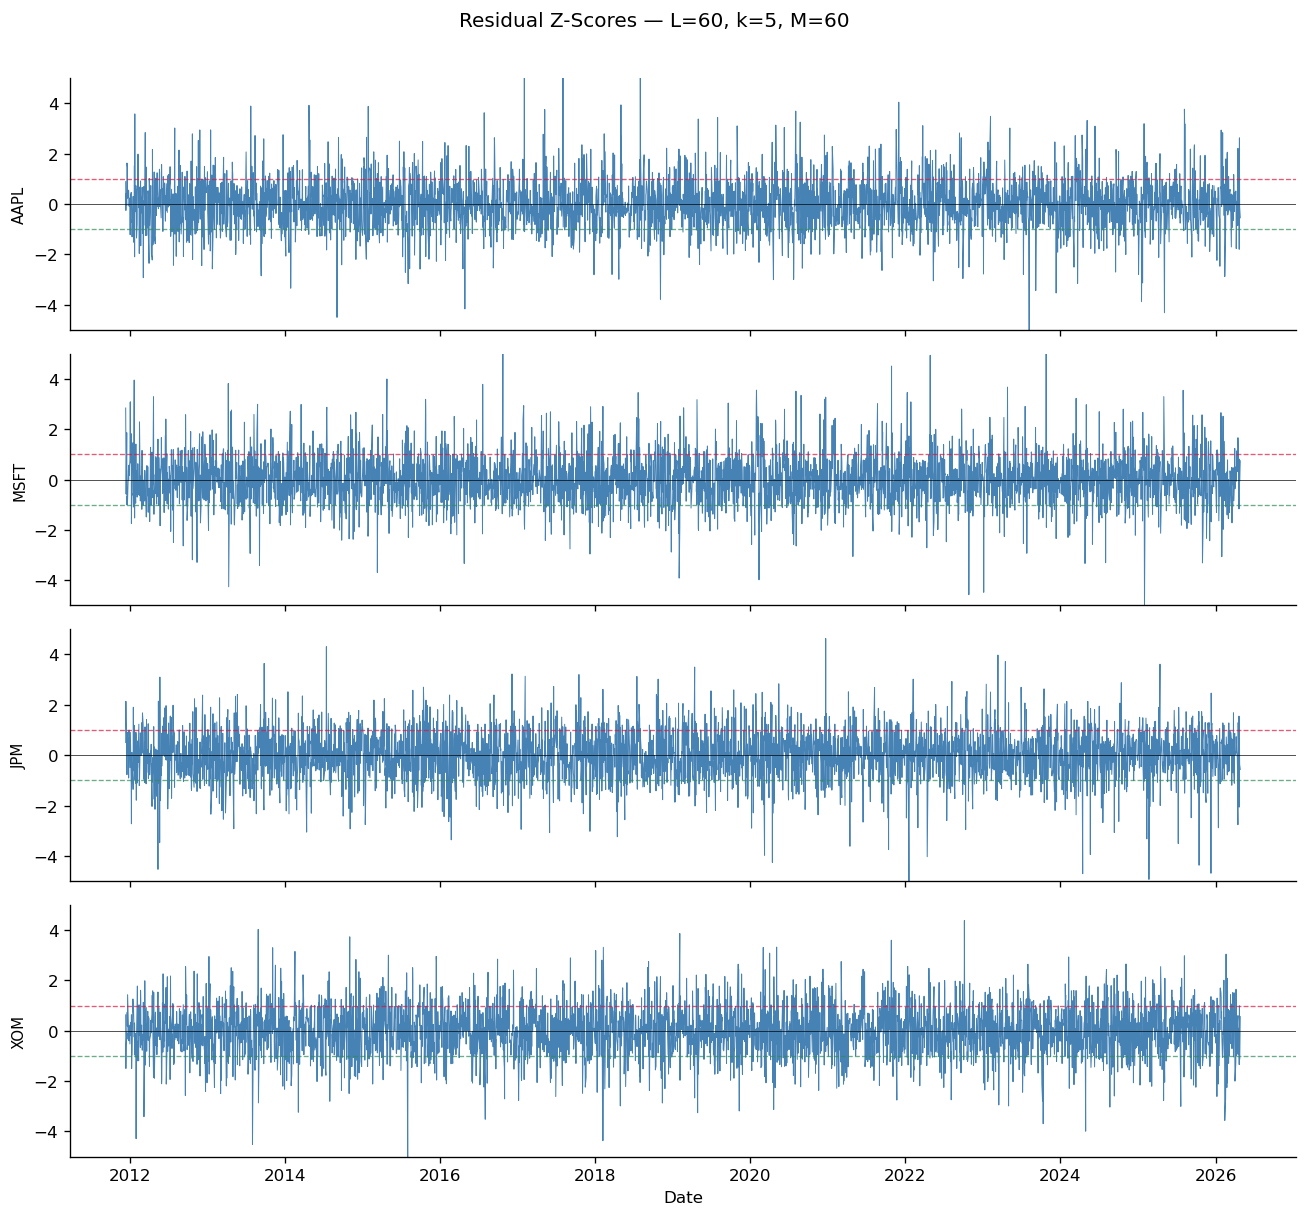

In [14]:
fig, axes = plt.subplots(len(example_tickers), 1, figsize=(11, 2.5 * len(example_tickers)), sharex=True)
if len(example_tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, example_tickers):
    z = zscores[ticker]
    ax.plot(z.index, z.values, linewidth=0.6, color="steelblue")
    ax.axhline( 1.0, color="crimson",   linewidth=0.8, linestyle="--", alpha=0.7)
    ax.axhline(-1.0, color="seagreen",  linewidth=0.8, linestyle="--", alpha=0.7)
    ax.axhline( 0.0, color="black",     linewidth=0.4, linestyle="-")
    ax.set_ylabel(ticker, fontsize=9)
    ax.set_ylim(-5, 5)

axes[-1].set_xlabel("Date")
fig.suptitle(f"Residual Z-Scores — L={L_MAIN}, k={K_MAIN}, M={M_MAIN}", y=1.01)
plt.tight_layout()
plt.show()

### Signal Construction

#### Threshold Signal

Enter a position only when the z-score crosses a threshold $c$:

$$s_{i,t} = \begin{cases} +1 & z_{i,t} < -c \\ -1 & z_{i,t} > +c \\ 0 & |z_{i,t}| \leq c \end{cases}$$

Main spec: $c = 1.0$. Robustness grid: $c \in \{0.75, 1.0, 1.5, 2.0\}$.

#### Quantile Signal

Each day, rank all stocks by z-score. Long the bottom $q = 10\%$ (most oversold), short the top $q = 10\%$ (most overbought). This keeps the number of active positions stable regardless of volatility regime.

In [15]:
# Threshold signal — main spec (c = 1.0)
c = THRESHOLD_MAIN
signal_threshold = pd.DataFrame(0.0, index=zscores.index, columns=zscores.columns)
signal_threshold[zscores < -c] =  1.0   # long: stock underperformed → expect reversion up
signal_threshold[zscores >  c] = -1.0   # short: stock outperformed → expect reversion down

long_counts  = (signal_threshold ==  1).sum(axis=1)
short_counts = (signal_threshold == -1).sum(axis=1)

print(f"Threshold signal (c={c})")
print(f"  Avg longs  per day : {long_counts.mean():.1f}")
print(f"  Avg shorts per day : {short_counts.mean():.1f}")
print(f"  Avg total active   : {(long_counts + short_counts).mean():.1f} / {len(zscores.columns)} stocks")

Threshold signal (c=1.0)
  Avg longs  per day : 26.8
  Avg shorts per day : 27.1
  Avg total active   : 53.9 / 200 stocks


In [16]:
# Quantile signal (q = 0.10)
lo = zscores.quantile(Q_MAIN,       axis=1)   # per-date lower quantile
hi = zscores.quantile(1 - Q_MAIN,   axis=1)   # per-date upper quantile

signal_quantile = pd.DataFrame(0.0, index=zscores.index, columns=zscores.columns)
signal_quantile[zscores.le(lo, axis=0)]  =  1.0
signal_quantile[zscores.ge(hi, axis=0)]  = -1.0

long_q  = (signal_quantile ==  1).sum(axis=1)
short_q = (signal_quantile == -1).sum(axis=1)

print(f"Quantile signal (q={Q_MAIN})")
print(f"  Avg longs  per day : {long_q.mean():.1f}")
print(f"  Avg shorts per day : {short_q.mean():.1f}")

Quantile signal (q=0.1)
  Avg longs  per day : 20.0
  Avg shorts per day : 20.0


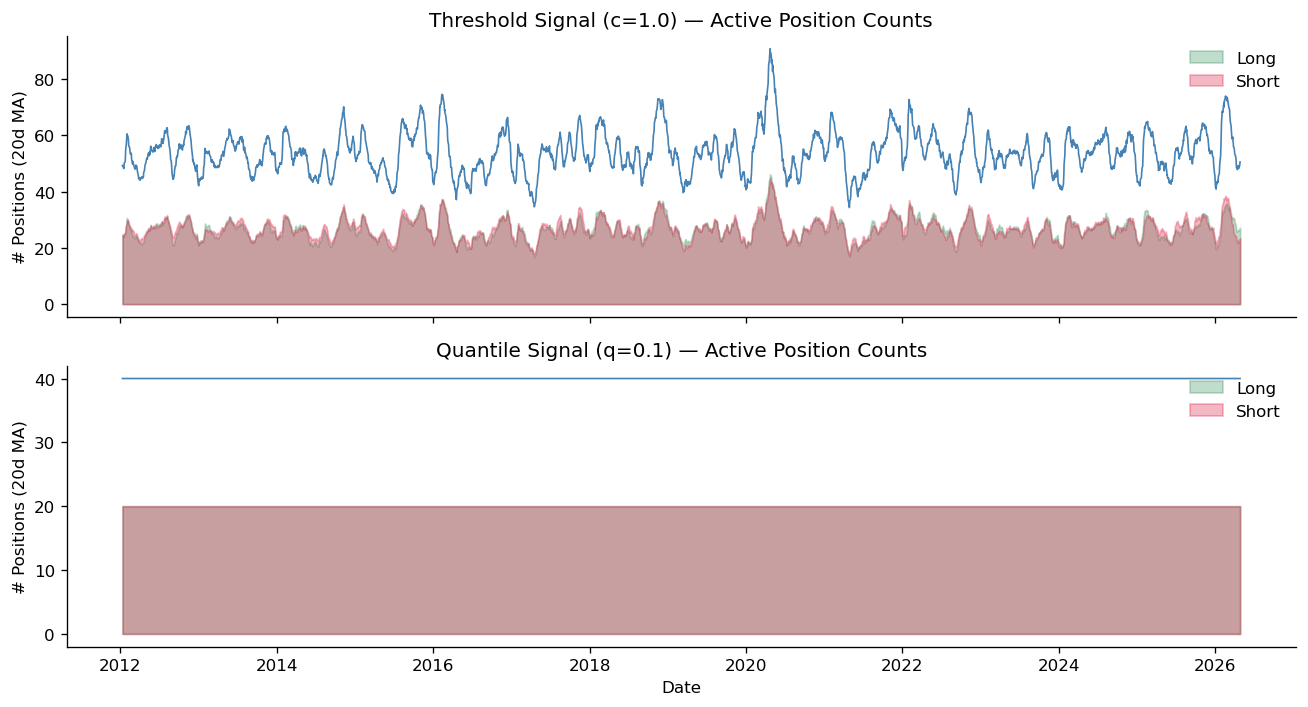

In [17]:
# Active position counts over time — threshold vs quantile
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax = axes[0]
total_thresh = long_counts + short_counts
ax.plot(total_thresh.index, total_thresh.rolling(20).mean(), color="steelblue", linewidth=1)
ax.fill_between(long_counts.index, 0, long_counts.rolling(20).mean(), alpha=0.3, color="seagreen", label="Long")
ax.fill_between(short_counts.index, 0, short_counts.rolling(20).mean(), alpha=0.3, color="crimson", label="Short")
ax.set_ylabel("# Positions (20d MA)")
ax.set_title(f"Threshold Signal (c={THRESHOLD_MAIN}) — Active Position Counts")
ax.legend(frameon=False)

ax = axes[1]
total_q = long_q + short_q
ax.plot(total_q.index, total_q.rolling(20).mean(), color="steelblue", linewidth=1)
ax.fill_between(long_q.index, 0, long_q.rolling(20).mean(), alpha=0.3, color="seagreen", label="Long")
ax.fill_between(short_q.index, 0, short_q.rolling(20).mean(), alpha=0.3, color="crimson", label="Short")
ax.set_ylabel("# Positions (20d MA)")
ax.set_xlabel("Date")
ax.set_title(f"Quantile Signal (q={Q_MAIN}) — Active Position Counts")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [18]:
# Parquet for DataFrames — faster and smaller than CSV
residuals.to_parquet(     f"{PROCESSED}/residual_returns.parquet")
zscores.to_parquet(       f"{PROCESSED}/residual_zscores.parquet")
evr.to_parquet(           f"{PROCESSED}/pca_explained_variance.parquet")
factor_returns.to_parquet(f"{PROCESSED}/pca_factor_returns.parquet")
signal_threshold.to_parquet(f"{PROCESSED}/signal_threshold_c{THRESHOLD_MAIN}.parquet")
signal_quantile.to_parquet( f"{PROCESSED}/signal_quantile_q{Q_MAIN}.parquet")

# Loadings: ndarray + column/index labels saved as a dict
loadings_payload = {
    "loadings": loadings_last,                                # (k, N)
    "components": [f"PC{j+1}" for j in range(K_MAIN)],
    "tickers": list(log_returns.columns),
    "date": str(log_returns.index[-1].date()),
}
with open(f"{PROCESSED}/pca_loadings.pkl", "wb") as f:
    pickle.dump(loadings_payload, f)

print("Saved:")
print(f"  {PROCESSED}/residual_returns.parquet")
print(f"  {PROCESSED}/residual_zscores.parquet")
print(f"  {PROCESSED}/pca_explained_variance.parquet")
print(f"  {PROCESSED}/pca_factor_returns.parquet")
print(f"  {PROCESSED}/signal_threshold_c{THRESHOLD_MAIN}.parquet")
print(f"  {PROCESSED}/signal_quantile_q{Q_MAIN}.parquet")
print(f"  {PROCESSED}/pca_loadings.pkl")

Saved:
  ../data/processed/residual_returns.parquet
  ../data/processed/residual_zscores.parquet
  ../data/processed/pca_explained_variance.parquet
  ../data/processed/pca_factor_returns.parquet
  ../data/processed/signal_threshold_c1.0.parquet
  ../data/processed/signal_quantile_q0.1.parquet
  ../data/processed/pca_loadings.pkl
